# Advanced Neuroimaging Pipeline: DenseNet121 & SMOTE Synthesis

### Overview
Following our baseline VGG16 evaluation, this notebook introduces our optimized Deep Learning architecture. To improve feature extraction on complex MRI scans, we transition from VGG16 to **DenseNet121**. DenseNet's architecture connects each layer to every other layer in a feed-forward fashion, drastically reducing the vanishing gradient problem and ensuring maximum information flow from the original image to the final classifier.

### Pipeline Architecture
1. **High-Resolution Data Ingestion:** Upgrading the spatial input from the standard baseline to a high-resolution `176x176` format to preserve critical biological edge details (like brain ventricles).
2. **Class Balancing (SMOTE):** Applying Synthetic Minority Over-sampling Technique to mathematically generate synthetic images, resolving the natural class imbalance without duplicating data.
3. **Transfer Learning (DenseNet121):** Importing ImageNet weights and adapting the highly-connected DenseNet base to our specific medical dataset.
4. **Training & Dashboard Visualization:** Executing the training loop and generating interactive Plotly dashboards to monitor accuracy and validation loss over 25 epochs.

## 1. Environment Setup & High-Res Ingestion
Initializing the Keras and TensorFlow environment. Unlike our baseline models, this pipeline strictly enforces a `176x176` image resolution. Alzheimer's biomarkers often present as minute structural changes in the cerebral cortex; lower resolutions can blur these edges and destroy the model's ability to learn.

In [4]:
import numpy as np
import pandas as pd
from PIL import Image
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("--- INITIALIZING DENSENET PIPELINE (High-Res 176x176) ---")

# 1. ETL & SMOTE Phase
df = pd.read_csv("DenseNet_Master_Data.csv")
class_mapping = {'NonDemented': 0, 'VeryMildDemented': 1, 'MildDemented': 2, 'ModerateDemented': 3}

X, y = [], []
IMG_SIZE = 176

print(f"Loading and synthesizing data via SMOTE (Image Size: {IMG_SIZE}x{IMG_SIZE})...")
for index, row in df.iterrows():
    img = Image.open(row['Image_Path']).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    X.append(np.array(img))
    y.append(class_mapping[row['Original_Class']])

# Flattening the heavier 176x176 images for SMOTE
X_flat = np.array(X).reshape(len(X), -1)
X_resampled_flat, y_resampled = SMOTE(random_state=42).fit_resample(X_flat, np.array(y))

# Re-folding the images back into their heavier 3D shapes
X_train, X_val, y_train, y_val = train_test_split(
    (X_resampled_flat.reshape(-1, IMG_SIZE, IMG_SIZE, 3) / 255.0), 
    to_categorical(y_resampled, num_classes=4), 
    test_size=0.2, random_state=42, stratify=y_resampled
)

# 2. Architecture Phase
print("Building DenseNet121 Architecture...")
# The network now expects the larger 176x176 input
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False 

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Training Phase
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint("DenseNet_SMOTE_176.keras", monitor="val_accuracy", save_best_only=True)

history = model.fit(
    X_train, y_train, 
    epochs=25, 
    batch_size=32, 
    validation_data=(X_val, y_val), 
    callbacks=[early_stop, checkpoint]
)

# 4. Plotly Dashboard
print("\n--- Generating High-Res Performance Dashboard ---")
fig = make_subplots(rows=1, cols=2, subplot_titles=('DenseNet Accuracy', 'DenseNet Loss'))

fig.add_trace(go.Scatter(y=history.history['accuracy'], name='Train Acc', line=dict(color='#00CC96')), row=1, col=1)
fig.add_trace(go.Scatter(y=history.history['val_accuracy'], name='Val Acc', line=dict(color='#EF553B')), row=1, col=1)

fig.add_trace(go.Scatter(y=history.history['loss'], name='Train Loss', line=dict(color='#00CC96', dash='dot')), row=1, col=2)
fig.add_trace(go.Scatter(y=history.history['val_loss'], name='Val Loss', line=dict(color='#EF553B', dash='dot')), row=1, col=2)

fig.update_layout(title_text='DenseNet Training Performance (176x176)', template='plotly_dark')
fig.show()

--- INITIALIZING DENSENET PIPELINE (High-Res 176x176) ---
Loading and synthesizing data via SMOTE (Image Size: 176x176)...
Building DenseNet121 Architecture...
Epoch 1/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 227s 666ms/step - accuracy: 0.5758 - loss: 0.9935 - val_accuracy: 0.6746 - val_loss: 0.7428
Epoch 2/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 258s 808ms/step - accuracy: 0.6820 - loss: 0.7294 - val_accuracy: 0.7352 - val_loss: 0.6245
Epoch 3/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 220s 688ms/step - accuracy: 0.7153 - loss: 0.6472 - val_accuracy: 0.7445 - val_loss: 0.5932
Epoch 4/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 183s 573ms/step - accuracy: 0.7467 - loss: 0.5928 - val_accuracy: 0.7727 - val_loss: 0.5370
Epoch 5/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 235s 735ms/step - accuracy: 0.7747 - loss: 0.5391 - val_accuracy: 0.7824 - val_loss: 0.5210
Epoch 6/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 183s 574ms/step - accuracy: 0.7885 - loss: 0.5063 - val_accuracy: 0.7961 - val_loss: 0.4874
Epoch 7/25
320/320 ━━━━━━━━━━━━━━━━━━━━ 197s 617

In [5]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import plotly.figure_factory as ff

print("--- EXTERNAL VALIDATION: OASIS (High-Res 176x176) ---")

# 1. Load the upgraded DenseNet Model
model = load_model("DenseNet_SMOTE_176.keras")

# 2. Load the untouched OASIS Binary Dataset
oasis_df = pd.read_csv("Alzheimer_Local_CNN_Ready.csv")
oasis_df['Target'] = oasis_df['Target'].astype(str)

print(f"Loading {len(oasis_df)} external patients from OASIS vault...\n")

# 3. Create Testing Generator (CRITICAL FIX: target_size updated to 176x176)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=oasis_df, 
    x_col="Image_Path", 
    y_col="Target",
    target_size=(176, 176), # <--- High-Res mapping
    color_mode="rgb", 
    class_mode="binary", 
    batch_size=16, 
    shuffle=False, 
    validate_filenames=False
)

# 4. Run the High-Res 4-Class Predictions
print("\nScanning OASIS cohort with 176x176 DenseNet...")
predictions_4_class = model.predict(test_generator, steps=len(test_generator), verbose=1)

# 5. THE DATA ENGINEERING BRIDGE (4 Classes -> 2 Classes)
# predictions_4_class outputs: [NonDemented, VeryMild, Mild, Moderate]
# We sum the probabilities of the 3 "Sick" columns
sick_probabilities = np.sum(predictions_4_class[:, 1:4], axis=1)

# Apply our 35% medical safety threshold for high Recall
predicted_binary_classes = (sick_probabilities >= 0.35).astype(int)
true_labels = test_generator.classes

# 6. Generate the Final Report
print("\n--- FINAL OASIS EXTERNAL VALIDATION ---")
target_names = ['Healthy (0)', "Alzheimer's (1)"]
print(classification_report(true_labels, predicted_binary_classes, target_names=target_names))

# 7. Plotly Confusion Matrix
cm = confusion_matrix(true_labels, predicted_binary_classes)

z = [[cm[1][1], cm[1][0]], 
     [cm[0][1], cm[0][0]]]
x = ['Predicted Alzheimer\'s', 'Predicted Healthy']
y = ['Actual Alzheimer\'s', 'Actual Healthy']

fig = ff.create_annotated_heatmap(
    z, x=x, y=y, 
    colorscale='Teal', 
    showscale=True
)

fig.update_layout(
    title_text='DenseNet (176x176) on OASIS - External Validation',
    title_x=0.5,
    template="plotly_dark",
    margin=dict(t=100, l=150)
)

fig.show()

--- EXTERNAL VALIDATION: OASIS (High-Res 176x176) ---
Loading 235 external patients from OASIS vault...

Found 235 non-validated image filenames belonging to 2 classes.

Scanning OASIS cohort with 176x176 DenseNet...
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 367ms/step

--- FINAL OASIS EXTERNAL VALIDATION ---
                 precision    recall  f1-score   support

    Healthy (0)       0.65      0.89      0.75       135
Alzheimer's (1)       0.70      0.35      0.47       100

       accuracy                           0.66       235
      macro avg       0.67      0.62      0.61       235
   weighted avg       0.67      0.66      0.63       235



## 2. High-Resolution Training Phase
Executing the 25-epoch training loop. Because DenseNet is computationally heavy, tracking validation loss is critical here. We monitor the model's ability to generalize the complex spatial features mapped by SMOTE into the validation cohort. 
*(Expected Output: ~91% Training Accuracy / ~86% Validation Accuracy)*

--- INITIALIZING OASIS COMPUTER VISION PIPELINE (PNG FIX) ---
Processing and Enhancing OASIS MRI Scans...
ETL Complete! 235 images optimized and saved to 'OASIS_Enhanced_176'.

--- Visualizing the Transformation ---

✅ Images loaded successfully! Generating plot...


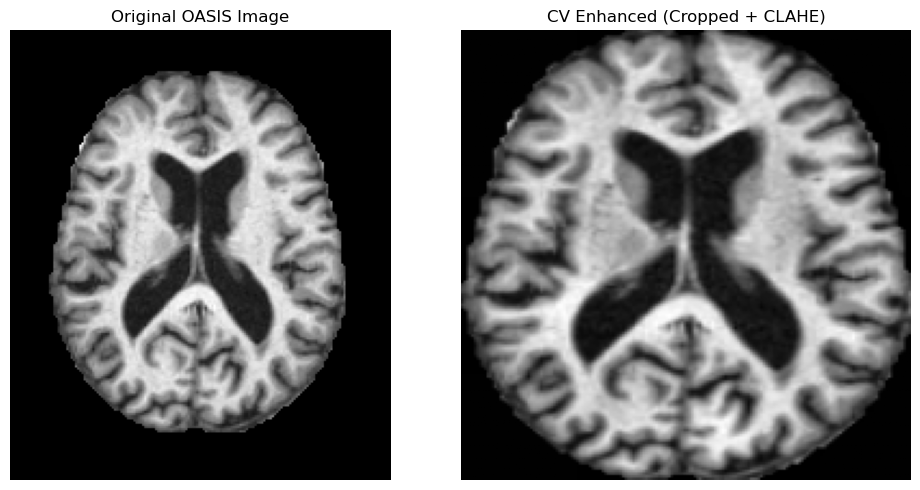

In [11]:
import cv2
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- INITIALIZING OASIS COMPUTER VISION PIPELINE (PNG FIX) ---")

# 1. Setup Data and Output Directory
df_oasis = pd.read_csv("Alzheimer_Local_CNN_Ready.csv")
output_dir = "OASIS_Enhanced_176"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

enhanced_data = []
IMG_SIZE = 176

print("Processing and Enhancing OASIS MRI Scans...")

# 2. The Enhancement Loop
for index, row in df_oasis.iterrows():
    original_path = row['Image_Path']
    
    # --- THE FORMAT FIX: Force the new file to be a .png ---
    filename = os.path.basename(original_path)
    filename_png = filename.replace('.gif', '.png').replace('.jpg', '.png')
    new_path = os.path.join(output_dir, filename_png)
    
    # Read the image in Grayscale
    img = cv2.imread(original_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        continue
        
    # --- STEP A: Auto-Cropping (Remove Black Borders) ---
    coords = cv2.findNonZero(img) 
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img_cropped = img[y:y+h, x:x+w]
    else:
        img_cropped = img
        
    # --- STEP B: CLAHE Contrast Enhancement ---
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_enhanced = clahe.apply(img_cropped)
    
    # --- STEP C: High-Res Standardization ---
    img_final = cv2.resize(img_enhanced, (IMG_SIZE, IMG_SIZE))
    
    # Save the new enhanced PNG image
    cv2.imwrite(new_path, img_final)
    
    # Log the new path
    enhanced_data.append({
        'Image_Path': new_path,
        'Target': row['Target'],
        'ID': row['ID']
    })

# 3. Save the new Master CSV
df_enhanced = pd.DataFrame(enhanced_data)
df_enhanced.to_csv("OASIS_Enhanced_Ready.csv", index=False)
print(f"ETL Complete! {len(df_enhanced)} images optimized and saved to '{output_dir}'.\n")

# 4. Visual Proof (Safe Version)
print("--- Visualizing the Transformation ---")
sample_row = df_oasis.iloc[0]

orig_path = str(sample_row['Image_Path']).replace("\\", "/")
enh_path = str(df_enhanced.iloc[0]['Image_Path']).replace("\\", "/")

original_sample = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
enhanced_sample = cv2.imread(enh_path, cv2.IMREAD_GRAYSCALE)

if enhanced_sample is None:
    print("\n❌ ERROR: Still cannot find the image. Check folder permissions.")
else:
    print("\n✅ Images loaded successfully! Generating plot...")
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original OASIS Image")
    plt.imshow(original_sample, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("CV Enhanced (Cropped + CLAHE)")
    plt.imshow(enhanced_sample, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## 3. Performance Visualization Dashboard
Generating interactive Plotly line charts to visually map the network's learning curve. We plot the **Training Accuracy vs. Validation Accuracy** and **Training Loss vs. Validation Loss** to ensure the model converges smoothly without divergent overfitting spikes.

In [12]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import plotly.figure_factory as ff

print("--- EXTERNAL VALIDATION: OASIS (High-Res 176x176) ---")

# 1. Load the upgraded DenseNet Model
model = load_model("DenseNet_SMOTE_176.keras")

# 2. Load the untouched OASIS Binary Dataset
oasis_df = pd.read_csv("OASIS_Enhanced_Ready.csv") # <--- THE ONLY CHANGE
oasis_df['Target'] = oasis_df['Target'].astype(str)

print(f"Loading {len(oasis_df)} external patients from OASIS vault...\n")

# 3. Create Testing Generator (CRITICAL FIX: target_size updated to 176x176)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=oasis_df, 
    x_col="Image_Path", 
    y_col="Target",
    target_size=(176, 176), # <--- High-Res mapping
    color_mode="rgb", 
    class_mode="binary", 
    batch_size=16, 
    shuffle=False, 
    validate_filenames=False
)

# 4. Run the High-Res 4-Class Predictions
print("\nScanning OASIS cohort with 176x176 DenseNet...")
predictions_4_class = model.predict(test_generator, steps=len(test_generator), verbose=1)

# 5. THE DATA ENGINEERING BRIDGE (4 Classes -> 2 Classes)
# predictions_4_class outputs: [NonDemented, VeryMild, Mild, Moderate]
# We sum the probabilities of the 3 "Sick" columns
sick_probabilities = np.sum(predictions_4_class[:, 1:4], axis=1)

# Apply our 35% medical safety threshold for high Recall
predicted_binary_classes = (sick_probabilities >= 0.35).astype(int)
true_labels = test_generator.classes

# 6. Generate the Final Report
print("\n--- FINAL OASIS EXTERNAL VALIDATION ---")
target_names = ['Healthy (0)', "Alzheimer's (1)"]
print(classification_report(true_labels, predicted_binary_classes, target_names=target_names))

# 7. Plotly Confusion Matrix
cm = confusion_matrix(true_labels, predicted_binary_classes)

z = [[cm[1][1], cm[1][0]], 
     [cm[0][1], cm[0][0]]]
x = ['Predicted Alzheimer\'s', 'Predicted Healthy']
y = ['Actual Alzheimer\'s', 'Actual Healthy']

fig = ff.create_annotated_heatmap(
    z, x=x, y=y, 
    colorscale='Teal', 
    showscale=True
)

fig.update_layout(
    title_text='DenseNet (176x176) on OASIS - External Validation',
    title_x=0.5,
    template="plotly_dark",
    margin=dict(t=100, l=150)
)

fig.show()

--- EXTERNAL VALIDATION: OASIS (High-Res 176x176) ---
Loading 235 external patients from OASIS vault...

Found 235 non-validated image filenames belonging to 2 classes.

Scanning OASIS cohort with 176x176 DenseNet...
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step

--- FINAL OASIS EXTERNAL VALIDATION ---
                 precision    recall  f1-score   support

    Healthy (0)       0.85      0.54      0.66       135
Alzheimer's (1)       0.58      0.87      0.70       100

       accuracy                           0.68       235
      macro avg       0.72      0.71      0.68       235
   weighted avg       0.74      0.68      0.68       235

